## Imports

In [ ]:
!pip install lightning TSInterpret torchmetrics pnpl lime

In [61]:
import pickle
import numpy as np
import random
import matplotlib.pyplot as plt
import seaborn as sns
from lime import lime_tabular
import lightning as L
import torch
import torch.nn as nn
import torchmetrics
from sklearn.metrics import roc_curve, auc, balanced_accuracy_score, jaccard_score
from torchmetrics import Precision, Recall, F1Score
from lightning.pytorch.callbacks import Callback
from torchmetrics.functional import recall
from pnpl.datasets import LibriBrainSpeech
from torch.utils.data import DataLoader

## Speech detection model

In [70]:
class SpeechModel(nn.Module):
    """
    Parameters:
        input_dim (int): Number of channels/features in the input tensor (usually SENSORS_SPEECH_MASK)
        model_dim (int): Dimensionality for the intermediate model representation.
        dropout_rate (float, optional): Dropout probability applied after convolutional and LSTM layers.
        lstm_layers (int, optional): Number of layers in the LSTM module.
        bi_directional (bool, optional): If True, uses a bidirectional LSTM; otherwise, a unidirectional LSTM.
        batch_norm (bool, optional): Indicates whether to use batch normalization.

    """
    def __init__(self, input_dim, model_dim, dropout_rate=0.3, lstm_layers = 1, bi_directional = False, batch_norm=False):
        super().__init__()
        self.conv = nn.Conv1d(
            in_channels=input_dim,
            out_channels=model_dim,
            kernel_size=3,
            padding=1,
        )
        self.lstm_layers = lstm_layers
        self.batch_norm = nn.BatchNorm1d(num_features=model_dim) if batch_norm else nn.Identity()
        self.conv_dropout = nn.Dropout(p=dropout_rate)
        self.lstm = nn.LSTM(
            input_size=model_dim,
            hidden_size=model_dim,
            num_layers=self.lstm_layers,
            dropout=dropout_rate,
            batch_first=True,
            bidirectional=bi_directional
        )
        self.lstm_dropout = nn.Dropout(p=dropout_rate)
        self.speech_classifier = nn.Linear(model_dim, 1)

    def forward(self, x):
        x = self.conv(x)
        x = self.batch_norm(x)
        x = self.conv_dropout(x)
        # LSTM expects (batch, seq_len, input_size)
        output, (h_n, c_n) = self.lstm(x.permute(0, 2, 1))
        last_layer_h_n = h_n
        if self.lstm_layers > 1:
            # handle more than one layer
            last_layer_h_n = h_n[-1, :, :]
            last_layer_h_n = last_layer_h_n.unsqueeze(0)
        output = self.lstm_dropout(last_layer_h_n)
        output = output.flatten(start_dim=0, end_dim=1)
        x = self.speech_classifier(output)
        return x


In [71]:
class SpeechClassifier(L.LightningModule):
    """
    Parameters:
        input_dim (int): Number of input channels/features. This is passed to the underlying SpeechModel.
        model_dim (int): Dimensionality of the intermediate model representation.
        learning_rate (float, optional): Learning rate for the optimizer.
        weight_decay (float, optional): Weight decay for the optimizer.
        batch_size (int, optional): Batch size used during training and evaluation.
        dropout_rate (float, optional): Dropout probability applied after convolutional and LSTM layers.
        smoothing (float, optional): Label smoothing factor applied in the BCEWithLogits loss.
        pos_weight (float, optional): Weight for the positive class in the BCEWithLogits loss.
        batch_norm (bool, optional): Indicates whether to use batch normalization.
        lstm_layers (int, optional): Number of layers in the LSTM module within the SpeechModel.
        bi_directional (bool, optional): If True, uses a bidirectional LSTM in the SpeechModel; otherwise, uses a unidirectional LSTM.
    """

    def __init__(self, input_dim, model_dim, learning_rate=1e-3, weight_decay=0.01, batch_size=32, dropout_rate=0.3, smoothing=0.1, pos_weight = 1.0 , batch_norm = False, lstm_layers = 1, bi_directional = False):
        super().__init__()
        self.save_hyperparameters()

        self.learning_rate = learning_rate
        self.weight_decay = weight_decay
        self.batch_size = batch_size
        self.model = SpeechModel(input_dim, model_dim, dropout_rate=dropout_rate, lstm_layers=lstm_layers, bi_directional=bi_directional, batch_norm=batch_norm)

        self.loss_fn = BCEWithLogitsLossWithSmoothing(smoothing=smoothing, pos_weight = pos_weight)

        self.val_step_outputs = []
        self.test_step_outputs = {}


    def forward(self, x):
            return self.model(x)

    def _shared_eval_step(self, batch, stage):
        x = batch[0]
        y = batch[1] # (batch, seq_len)

        logits = self(x)
        loss = self.loss_fn(logits, y.unsqueeze(1).float())
        probs = torch.sigmoid(logits)
        y_probs = probs.detach().cpu()

        y_true = batch[1].detach().cpu()
        meg = x.detach().cpu()

        self.log(f'{stage}_loss', loss, on_step=False, on_epoch=True, batch_size=self.batch_size)
        return loss


    def training_step(self, batch, batch_idx):
        return self._shared_eval_step(batch, "train")


    def validation_step(self, batch, batch_idx):
        return self._shared_eval_step(batch, "val")


    def test_step(self, batch, batch_idx):
        x = batch[0]
        y = batch[1]  # (batch, seq_len)

        # ugly, taking care of only one label
        if len(y.shape) != 1:
            y = y.flatten(start_dim=0, end_dim=1).view(-1, 1)  # (batch, seq_len) -> (batch * seq_len, 1)
        else:
            y = y.unsqueeze(1)

        logits = self(x)
        loss = self.loss_fn(logits, y.float())
        probs = torch.sigmoid(logits)

        # Append data to the defaultdict
        # Ensure keys exist before appending
        if "y_probs" not in self.test_step_outputs:
            self.test_step_outputs["y_probs"] = []
        if "y_true" not in self.test_step_outputs:
            self.test_step_outputs["y_true"] = []
        if "meg" not in self.test_step_outputs:
            self.test_step_outputs["meg"] = []

        # Append data
        if y.shape[-1] != 1:
            self.test_step_outputs["y_probs"].extend(
                probs.detach().view(x.shape[0], x.shape[-1]).cpu())  # (batch, seq_len)
        else:
            self.test_step_outputs["y_probs"].extend(
                probs.detach().view(x.shape[0], 1).cpu())  # (batch, seq_len)

        self.test_step_outputs["y_true"].extend(batch[1].detach().cpu())  # (batch, seq_len)
        self.test_step_outputs["meg"].extend(x.detach().cpu())  # MEG data (batch, channels, seq_len)

        return self._shared_eval_step(batch, "test")

    def configure_optimizers(self):
        optimizer = torch.optim.AdamW(self.parameters(), lr=self.learning_rate, weight_decay=self.weight_decay)
        return optimizer


class BCEWithLogitsLossWithSmoothing(nn.Module):
    def __init__(self, smoothing=0.1, pos_weight = 1.0):
        """
        Binary Cross-Entropy Loss with Deterministic Label Smoothing.

        Parameters:
            smoothing (float): Smoothing factor. Must be between 0 and 1.
            pos_weight (float): Weight for the positive class.
        """
        super().__init__()
        self.smoothing = smoothing
        self.bce_loss = nn.BCEWithLogitsLoss(pos_weight=torch.tensor([pos_weight]))

    def forward(self, logits, target):
        target = target.float()  # Ensure target is a float tensor
        target_smoothed = target * (1 - self.smoothing) + self.smoothing * 0.5
        return self.bce_loss(logits, target_smoothed)

## Load model

In [72]:
# Setup checkpoint path
checkpoint_path = "speech_model.ckpt"

model = SpeechClassifier.load_from_checkpoint(checkpoint_path)

# Set a fixed seed for reproducibility (just in case)
L.seed_everything(42)

# Load the SpeechClassifier model from checkpoint
SENSORS_SPEECH_MASK = [18, 20, 22, 23, 45, 120, 138, 140, 142, 143, 145,
                       146, 147, 149, 175, 176, 177, 179, 180, 198, 271, 272, 275]
model = SpeechClassifier.load_from_checkpoint(
    checkpoint_path=checkpoint_path,
    input_dim=len(SENSORS_SPEECH_MASK),
    model_dim=100,
    learning_rate=1e-3,
    dropout_rate=0.5,
    lstm_layers=2,
    weight_decay=0.01,
    batch_norm=False,
    bi_directional=False
)

# Initialize trainer and test loaded model
trainer = L.Trainer(devices="auto")

INFO: Seed set to 42
INFO:lightning.fabric.utilities.seed:Seed set to 42
INFO: 💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
INFO:lightning.pytorch.utilities.rank_zero:💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
INFO: GPU available: False, used: False
INFO:lightning.pytorch.utilities.rank_zero:GPU available: False, used: False
INFO: TPU available: False, using: 0 TPU cores
INFO:lightning.pytorch.utilities.rank_zero:TPU available: False, using: 0 TPU cores


## Load data

In [7]:
# Set up base path for dataset and related files (base_path is assumed to be set in the cells below!)
base_path = "./libribrain"
try:
    import google.colab  # This module is only available in Colab.
    in_colab = True
    base_path = "/content"  # This is the folder displayed in the Colab sidebar
except ImportError:
    in_colab = False

num_workers = 2 if in_colab else 0

# For testing, we'll use all sessions from Sherlock 7
test_run_keys = [("0","1","Sherlock7","1")]
test_data = LibriBrainSpeech(
  data_path=f"{base_path}/data/",
  include_run_keys=test_run_keys,
  standardize=True,
  tmin=0.0,
  tmax=0.8,
  preload_files = True
)
test_loader = DataLoader(test_data, batch_size=32, shuffle=False, num_workers=num_workers)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


Sherlock7/derivatives/serialised/sub-0_s(…):   0%|          | 0.00/402M [00:00<?, ?B/s]

(…)-0_ses-1_task-Sherlock7_run-1_events.tsv: 0.00B [00:00, ?B/s]

Done!
calculated stats for:  ('0', '1', 'Sherlock7', '1')


In [10]:
# These are the sensors we identified as being particularly useful
SENSORS_SPEECH_MASK = [18, 20, 22, 23, 45, 120, 138, 140, 142, 143, 145,
                       146, 147, 149, 175, 176, 177, 179, 180, 198, 271, 272, 275]

class FilteredDataset(torch.utils.data.Dataset):
    """
    Parameters:
        dataset: LibriBrain dataset.
        limit_samples (int, optional): If provided, limits the length of the dataset to this
                          number of samples.
        speech_silence_only (bool, optional): If True, only includes segments that are either
                          purely speech or purely silence (with additional balancing).
        apply_sensors_speech_mask (bool, optional): If True, applies a fixed sensor mask to the sensor
                          data in each sample.
    """
    def __init__(self,
                 dataset,
                 limit_samples=None,
                 disable=False,
                 apply_sensors_speech_mask=True):
        self.dataset = dataset
        self.limit_samples = limit_samples
        self.apply_sensors_speech_mask = apply_sensors_speech_mask

        # These are the sensors we identified:
        self.sensors_speech_mask = SENSORS_SPEECH_MASK

        self.balanced_indices = list(range(len(dataset.samples)))
        # Shuffle the indices
        self.balanced_indices = random.sample(self.balanced_indices, len(self.balanced_indices))

    def __len__(self):
        """Returns the number of samples in the filtered dataset."""
        if self.limit_samples is not None:
            return self.limit_samples
        return len(self.balanced_indices)

    def __getitem__(self, index):
        # Map index to the original dataset using balanced indices
        original_idx = self.balanced_indices[index]
        if self.apply_sensors_speech_mask:
            sensors = self.dataset[original_idx][0][self.sensors_speech_mask]
        else:
            sensors = self.dataset[original_idx][0][:]
        label_from_the_middle_idx = self.dataset[original_idx][1].shape[0] // 2
        return [sensors, self.dataset[original_idx][1][label_from_the_middle_idx]]


# Conditionally set num_workers to avoid multiprocessing issues (try increasing if performance is problematic)
num_workers = 2 if in_colab else 0

test_data_filtered = FilteredDataset(test_data)
test_loader_filtered = DataLoader(test_data_filtered, batch_size=32, shuffle=False, num_workers=num_workers)
print(f"Test data contains {len(test_data_filtered)} samples\n")

# Let's look at the first batch:
# first_batch = next(iter(test_loader_filtered))
# inputs, labels = first_batch

Test data contains 1625 samples



In [31]:
first_batch = next(iter(test_loader_filtered))
inputs, labels = first_batch
print(inputs.shape, labels.shape)

torch.Size([32, 23, 200]) torch.Size([32])


In [56]:
inds_1 = np.where(labels==1)[0]
num_ones = len(inds_1)

inds_0 = np.where(labels==0)[0]
num_zeros = len(inds_0)

ave_signal_1 = np.zeros((num_ones, 200))
ave_signal_0 = np.zeros((num_zeros, 200))
cntr = 0
for i in inds_1:
  ave_signal_1[cntr] =  inputs[i, :, :].mean(axis=0)
  cntr+=1
cntr = 0
for i in inds_0:
  ave_signal_0[cntr] =  inputs[i, :, :].mean(axis=0)
  cntr+=1


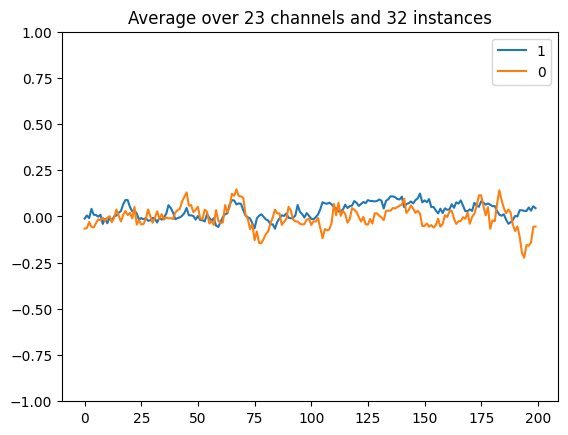

In [59]:
plt.figure()
plt.plot(np.arange(inputs.shape[-1]), ave_signal_1.mean(axis=0), label="1")
plt.plot(np.arange(inputs.shape[-1]), ave_signal_0.mean(axis=0), label="0")
plt.legend()
plt.title("Average over 23 channels and 32 instances")
plt.ylim([-1,1])
plt.show()

## TSInterpret

In [32]:
from TSInterpret.InterpretabilityModels.Saliency.TSR import TSR

n_timesteps = inputs.shape[-1]
n_features = len(SENSORS_SPEECH_MASK)
curr_input = np.array([inputs[0, :, :]]) # dims = 1 x 23 x 200

int_mod = TSR(
    model,
    n_timesteps,
    n_features,
    method='IG', # Integrated Gradients (IG)
    mode="feat" # second dim is 'time' or 'feat'
)
item = curr_input
label = labels[0]

exp = int_mod.explain(item, labels=label, TSR =True)

IndexError: index 1 is out of bounds for dimension 1 with size 1

In [ ]:
%matplotlib inline
int_mod.plot(item,exp)

In [37]:
from TSInterpret.InterpretabilityModels.leftist.leftist import LEFTIST

leftist = LEFTIST(
    model,
    (np.array(inputs), np.array(labels)),
    mode='feat',
    backend='PYT',
    learning_process_name='Lime',
    transform_name="background",
    explanation_size=1,
    nb_neighbors=1000
  )

explained_instance = np.array([inputs[0, :, :]]) # dims = 1 x 23 x 200
label = np.array(labels[0])

explanations = leftist.explain(explained_instance,label)

RuntimeError: Given groups=1, weight of size [100, 23, 3], expected input[23000, 1, 200] to have 23 channels, but got 1 channels instead

In [75]:
explainer = lime_tabular.RecurrentTabularExplainer(
    np.array(inputs),
    mode="classification",
    training_labels = np.array(labels),
    feature_names = [str(i) for i in range(n_features)],
    discretize_continuous = False,
    class_names = ["Silence", "Speech"],
    discretizer = 'decile'
)

In [76]:
exp = explainer.explain_instance(
    np.array(inputs[0,:,:]),
    model.forward,
    num_features=n_features,
    labels=(1,)
  )

TypeError: conv1d() received an invalid combination of arguments - got (numpy.ndarray, Parameter, Parameter, tuple, tuple, tuple, int), but expected one of:
 * (Tensor input, Tensor weight, Tensor bias = None, tuple of ints stride = 1, tuple of ints padding = 0, tuple of ints dilation = 1, int groups = 1)
      didn't match because some of the arguments have invalid types: (!numpy.ndarray!, !Parameter!, !Parameter!, !tuple of (int,)!, !tuple of (int,)!, !tuple of (int,)!, !int!)
 * (Tensor input, Tensor weight, Tensor bias = None, tuple of ints stride = 1, str padding = "valid", tuple of ints dilation = 1, int groups = 1)
      didn't match because some of the arguments have invalid types: (!numpy.ndarray!, !Parameter!, !Parameter!, !tuple of (int,)!, !tuple of (int,)!, !tuple of (int,)!, !int!)


In [107]:
model = model.eval()
logits = model(inputs)
sig_probs = torch.sigmoid(logits).detach().numpy()
y_preds = (sig_probs >= 0.5).astype(int).flatten()
soft_probs = torch.softmax(logits, dim=0).detach().numpy().flatten()

In [109]:
logits

tensor([[ 0.2517],
        [-0.0943],
        [ 0.7285],
        [ 1.3419],
        [ 0.1121],
        [ 0.5423],
        [-1.7491],
        [ 0.5501],
        [-1.7817],
        [ 1.3286],
        [-0.3477],
        [ 1.8207],
        [-0.4980],
        [ 0.8836],
        [-0.6343],
        [-1.4862],
        [-0.7459],
        [-0.8953],
        [ 0.4216],
        [-1.4227],
        [-1.4909],
        [ 0.2205],
        [-0.0807],
        [ 0.2956],
        [ 1.5601],
        [-1.4484],
        [ 0.0548],
        [ 1.3895],
        [ 0.4258],
        [ 0.7271],
        [ 0.9649],
        [ 1.4387]], grad_fn=<AddmmBackward0>)